# Inspect bulk transcriptomics datasets (ARCHS4, dense `.h5ad`)

Mirrors the single-cell `inspect_data.ipynb`, adapted for **bulk**:
- `X` is **dense `uint32`** (raw counts), not sparse CSR.
- Metadata is harmonized by `normalize_metadata.py` → `tissue_harmonized` / `disease_harmonized`
  (raw `source_name_ch1` / `characteristics_ch1` preserved alongside).
- Samples group by **`series_id`** (GSE study) — the unit used for leakage-free splits.

Set `DATASET` below to `"protein_mapped"` (≈20k UniProt cols, lighter) or `"all_transcripts"` (≈67k genes).

In [1]:
import numpy as np
import pandas as pd
import h5py
import anndata as ad
import matplotlib.pyplot as plt
from pathlib import Path

DATASET = "protein_mapped"   # "protein_mapped" (UniProt) or "all_transcripts" (HGNC symbols)

_here = Path.cwd()
H5AD = next(p for p in [
    _here / "output" / DATASET / "expression.h5ad",
    _here / "transcriptomics" / "bulk" / "output" / DATASET / "expression.h5ad",
    _here.parent / "output" / DATASET / "expression.h5ad",
] if p.exists())
print("Inspecting:", H5AD)

Inspecting: C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\protgpt\transcriptomics\bulk\output\protein_mapped\expression.h5ad


In [2]:
# Load obs/var only — the dense X (20-45 GB) stays on disk (backed).
adata = ad.read_h5ad(H5AD, backed="r")
meta = adata.obs.copy()
features = adata.var_names.to_list()
n_samp, n_feat = adata.shape
adata.file.close()

print(f"samples x features : {n_samp:,} x {n_feat:,}")
print(f"feature ids        : {features[:3]} ...")
print(f"obs columns        : {list(meta.columns)}")
meta.head()

samples x features : 680,216 x 20,272
feature ids        : ['A0A024RBG1', 'A0A075B6H7', 'A0A075B6H8'] ...
obs columns        : ['sample_id', 'geo_accession', 'series_id', 'source_name_ch1', 'characteristics_ch1', 'extract_protocol_ch1', 'title', 'tissue_harmonized', 'disease_harmonized']


,sample_id,geo_accession,series_id,source_name_ch1,characteristics_ch1,extract_protocol_ch1,title,tissue_harmonized,disease_harmonized
sample_id,,,,,,,,,
GSM1000981,GSM1000981,GSM1000981,GSE29282,Human DLBCL cel line,"treatment: siNT,cell line: OCI-LY1",ChIP-seq libraries were prepared using the Ill...,OCI-LY1_48hrs_mRNAseq_3x_siNT_R1,,
GSM1000982,GSM1000982,GSM1000982,GSE29282,Human DLBCL cel line,"treatment: siNT,cell line: OCI-LY1",ChIP-seq libraries were prepared using the Ill...,OCI-LY1_48hrs_mRNAseq_3x_siNT_R2,,
GSM1000983,GSM1000983,GSM1000983,GSE29282,Human DLBCL cel line,"treatment: siNT,cell line: OCI-LY1",ChIP-seq libraries were prepared using the Ill...,OCI-LY1_48hrs_mRNAseq_3x_siNT_R3,,
GSM1000984,GSM1000984,GSM1000984,GSE29282,Human DLBCL cel line,"treatment: siBCL6,cell line: OCI-LY1",ChIP-seq libraries were prepared using the Ill...,OCI-LY1_48hrs_mRNAseq_3x_siBCL6_R1,,
GSM1000985,GSM1000985,GSM1000985,GSE29282,Human DLBCL cel line,"treatment: siBCL6,cell line: OCI-LY1",ChIP-seq libraries were prepared using the Ill...,OCI-LY1_48hrs_mRNAseq_3x_siBCL6_R2,,


In [3]:
# X is DENSE uint32 -> no indptr tricks. Sample contiguous row-windows (fast for chunked
# dense) spread across the file, and compute per-sample QC on that working sample.
def sample_rows(n_windows=100, win=100, seed=0):
    with h5py.File(H5AD, "r") as f:
        N = f["X"].shape[0]
        win = min(win, N // n_windows)
        starts = np.linspace(0, N - win, n_windows).astype(int)
        blocks, idxs = [], []
        for st in starts:
            blocks.append(np.asarray(f["X"][st:st + win, :]))
            idxs.append(np.arange(st, st + win))
    return np.vstack(blocks), np.concatenate(idxs)

Xs, samp_idx = sample_rows()                       # ~10k samples x n_feat (dense)
meta_s = meta.iloc[samp_idx].reset_index(drop=True)
meta_s["total_counts"]   = Xs.sum(1)
meta_s["genes_detected"] = (Xs > 0).sum(1)
print(f"working sample: {Xs.shape[0]:,} x {Xs.shape[1]:,}  ({Xs.nbytes/1e9:.1f} GB in RAM)")

working sample: 10,000 x 20,272  (0.8 GB in RAM)


## Value distribution & dynamic range

value range (nonzero): 1-52,413,279, mean 1530.5  (uint32)
density (nonzero frac): 75.5%


values > 16-bit (65535): 0.16%   > float32-exact (2^24): 0.0000%   <- why uint32, not float32


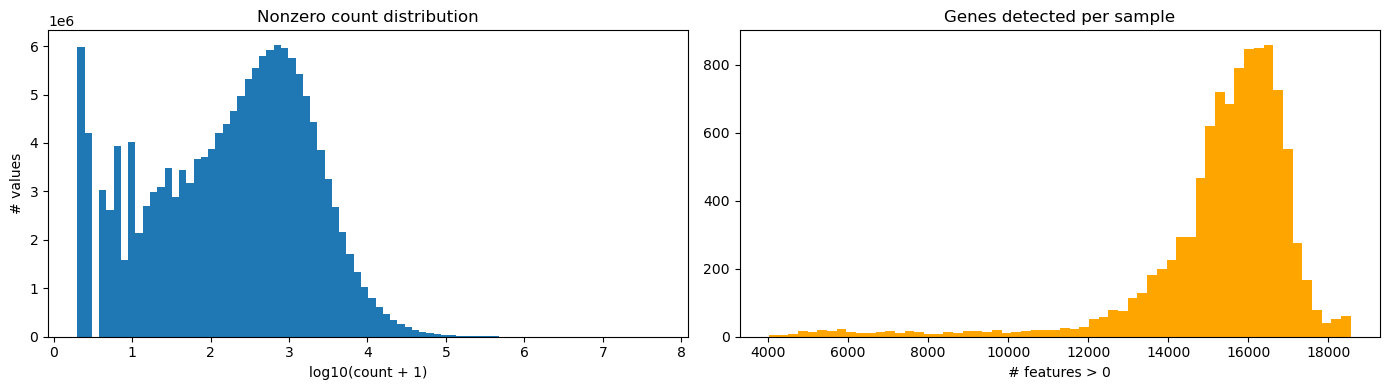

In [4]:
nz = Xs[Xs > 0].astype(np.int64)               # nonzero counts
print(f"value range (nonzero): {nz.min()}-{nz.max():,}, mean {nz.mean():.1f}  (uint32)")
print(f"density (nonzero frac): {(Xs > 0).mean():.1%}")
print(f"values > 16-bit (65535): {(nz > 65535).mean()*100:.2f}%   "
      f"> float32-exact (2^24): {(nz > 2**24).mean()*100:.4f}%   <- why uint32, not float32")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(np.log10(nz + 1), bins=80)
ax[0].set_title("Nonzero count distribution"); ax[0].set_xlabel("log10(count + 1)"); ax[0].set_ylabel("# values")
ax[1].hist(meta_s["genes_detected"], bins=60, color="orange")
ax[1].set_title("Genes detected per sample"); ax[1].set_xlabel("# features > 0")
plt.tight_layout(); plt.show()

## Harmonized metadata distributions

tissue_harmonized coverage: 38.6%  |  99 distinct tissues


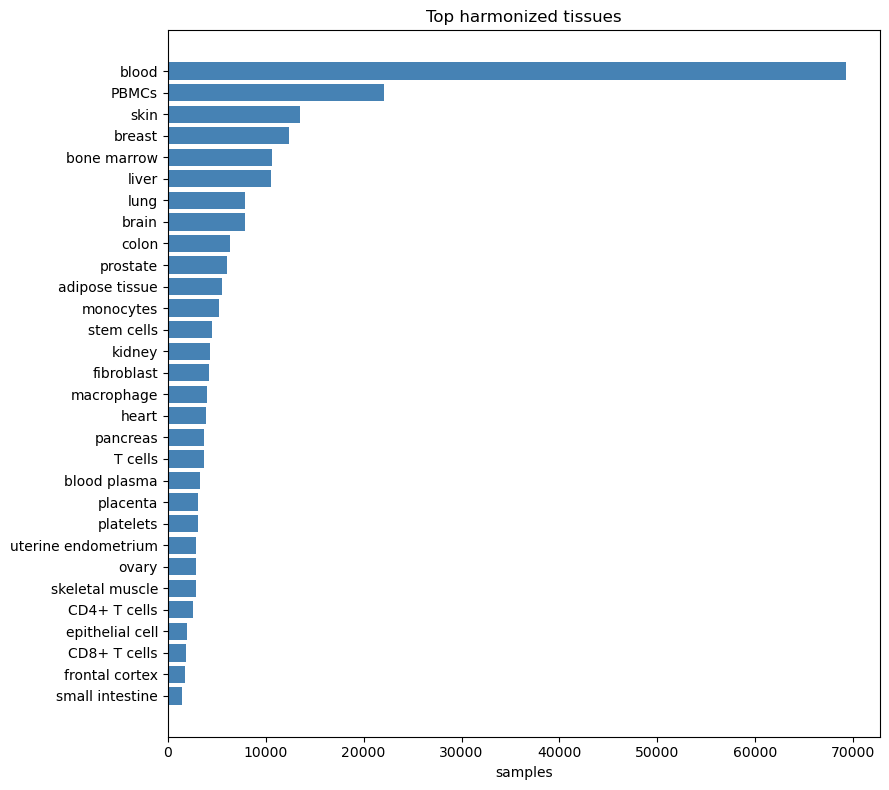

In [5]:
def _nonempty(col):
    return meta[col].astype(str).replace("", np.nan).dropna()

tc = _nonempty("tissue_harmonized").value_counts().head(30)
cov_t = (meta["tissue_harmonized"].astype(str).str.len() > 0).mean()
print(f"tissue_harmonized coverage: {cov_t:.1%}  |  {_nonempty('tissue_harmonized').nunique()} distinct tissues")

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(tc.index[::-1], tc.values[::-1], color="steelblue")
ax.set_title("Top harmonized tissues"); ax.set_xlabel("samples")
plt.tight_layout(); plt.show()

disease_harmonized coverage: 8.0%  |  104 distinct diseases


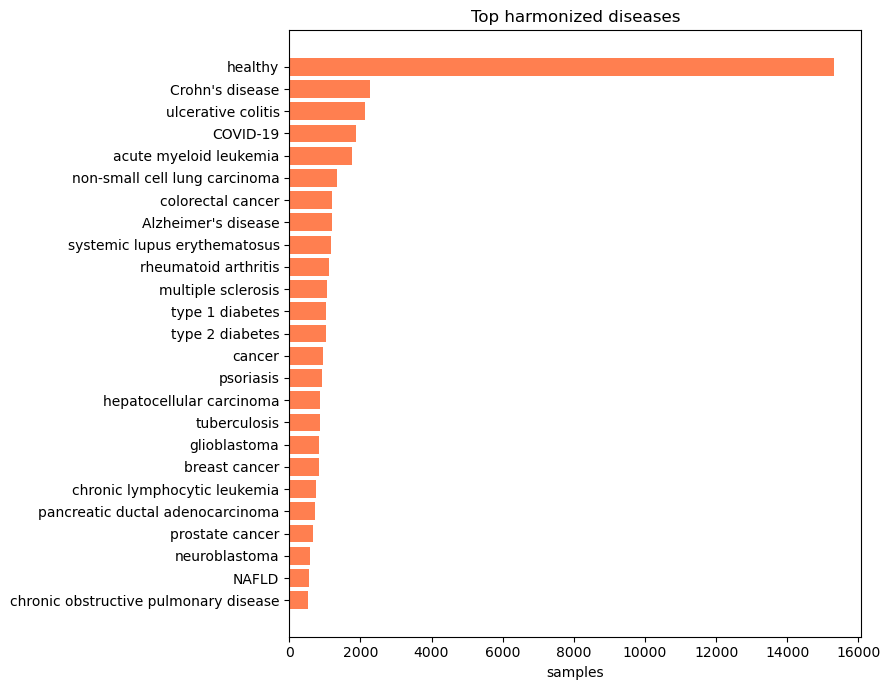

In [6]:
dc = _nonempty("disease_harmonized").value_counts().head(25)
cov_d = (meta["disease_harmonized"].astype(str).str.len() > 0).mean()
print(f"disease_harmonized coverage: {cov_d:.1%}  |  {_nonempty('disease_harmonized').nunique()} distinct diseases")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(dc.index[::-1], dc.values[::-1], color="coral")
ax.set_title("Top harmonized diseases"); ax.set_xlabel("samples")
plt.tight_layout(); plt.show()

## Per-sample QC metrics (working sample)

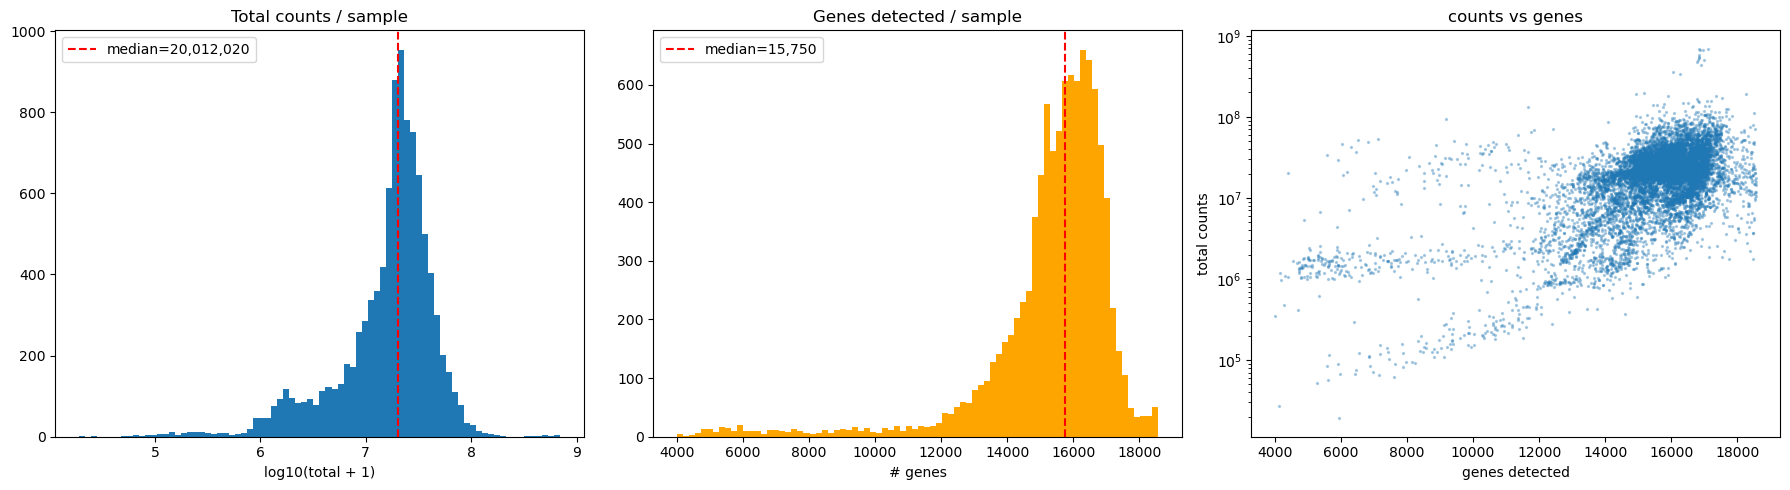

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(np.log10(meta_s["total_counts"] + 1), bins=80)
axes[0].axvline(np.log10(meta_s["total_counts"].median() + 1), color="red", ls="--",
                label=f'median={meta_s["total_counts"].median():,.0f}')
axes[0].set_title("Total counts / sample"); axes[0].set_xlabel("log10(total + 1)"); axes[0].legend()
axes[1].hist(meta_s["genes_detected"], bins=80, color="orange")
axes[1].axvline(meta_s["genes_detected"].median(), color="red", ls="--",
                label=f'median={meta_s["genes_detected"].median():,.0f}')
axes[1].set_title("Genes detected / sample"); axes[1].set_xlabel("# genes"); axes[1].legend()
axes[2].scatter(meta_s["genes_detected"], meta_s["total_counts"], s=2, alpha=0.3)
axes[2].set_yscale("log"); axes[2].set_xlabel("genes detected"); axes[2].set_ylabel("total counts")
axes[2].set_title("counts vs genes")
plt.tight_layout(); plt.show()

## Expression matrix statistics (per-feature, on sample)

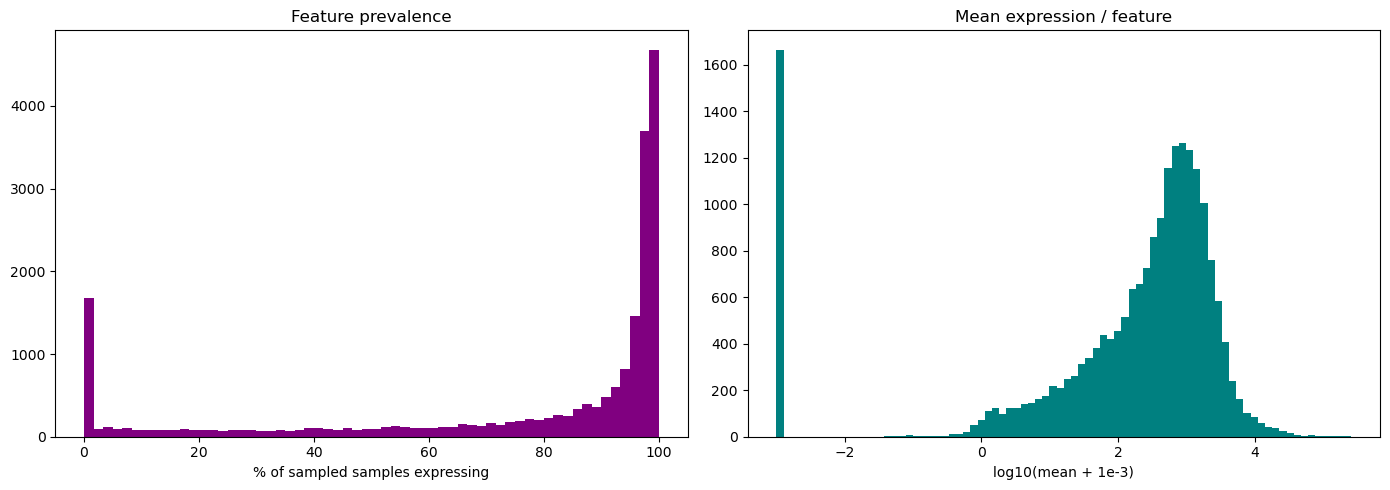

features in >50% of sampled samples: 16,109 / 20,272
features never seen in sample      : 1,664 / 20,272


In [8]:
samples_per_feat = (Xs > 0).sum(0)
mean_per_feat = Xs.mean(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(samples_per_feat / Xs.shape[0] * 100, bins=60, color="purple")
axes[0].set_title("Feature prevalence"); axes[0].set_xlabel("% of sampled samples expressing")
axes[1].hist(np.log10(mean_per_feat + 1e-3), bins=80, color="teal")
axes[1].set_title("Mean expression / feature"); axes[1].set_xlabel("log10(mean + 1e-3)")
plt.tight_layout(); plt.show()

print(f"features in >50% of sampled samples: {(samples_per_feat > Xs.shape[0]*0.5).sum():,} / {n_feat:,}")
print(f"features never seen in sample      : {(samples_per_feat == 0).sum():,} / {n_feat:,}")

## Per-tissue profiles (top harmonized tissues)

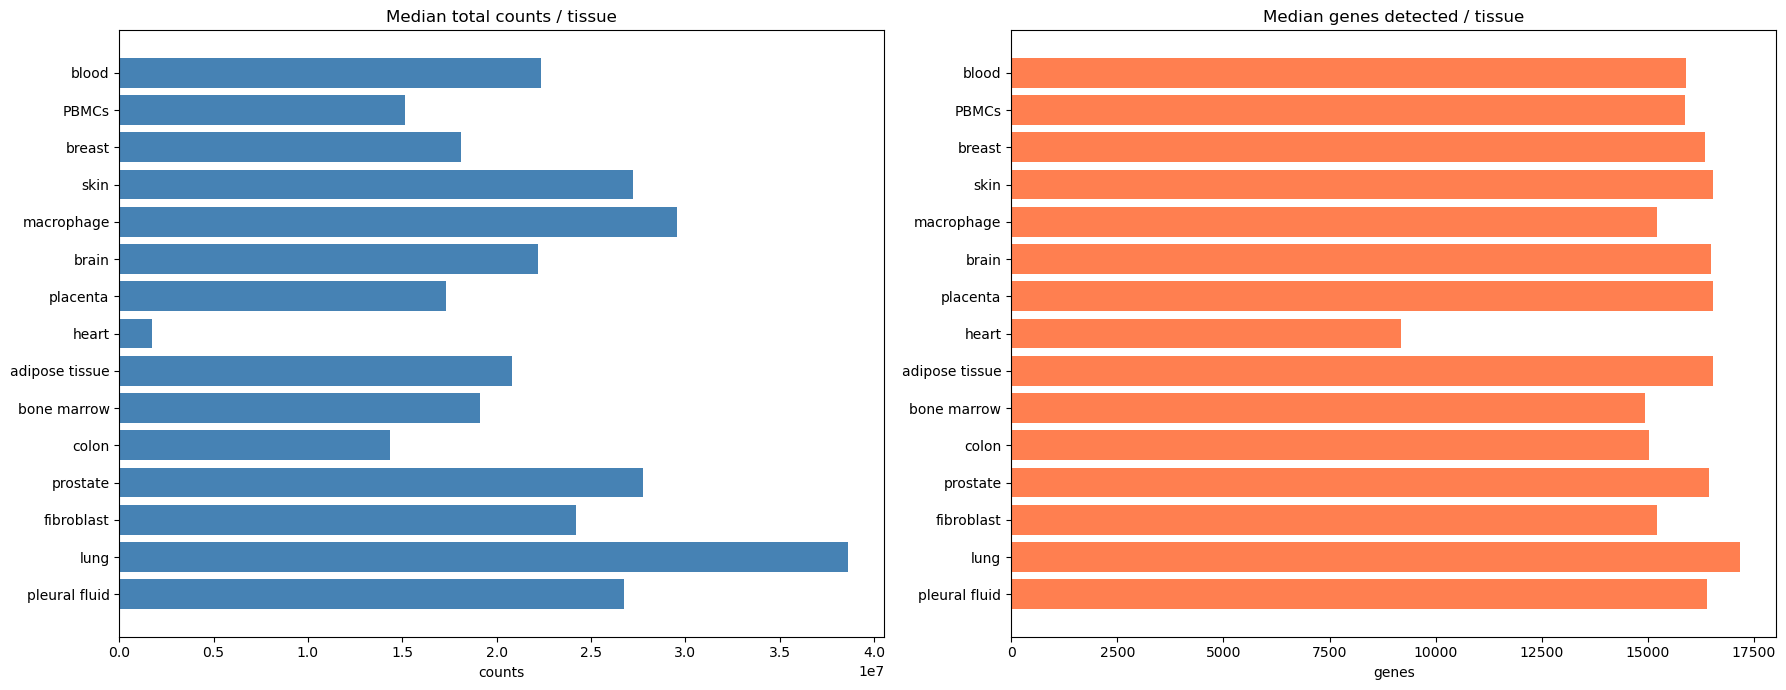

In [9]:
tt = meta_s["tissue_harmonized"].astype(str).replace("", np.nan)
top_t = tt.value_counts().head(15).index.tolist()
sub = meta_s.assign(t=tt)[tt.isin(top_t)]
g = sub.groupby("t")
med_c = g["total_counts"].median().loc[top_t]
med_g = g["genes_detected"].median().loc[top_t]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].barh(med_c.index[::-1], med_c.values[::-1], color="steelblue")
axes[0].set_title("Median total counts / tissue"); axes[0].set_xlabel("counts")
axes[1].barh(med_g.index[::-1], med_g.values[::-1], color="coral")
axes[1].set_title("Median genes detected / tissue"); axes[1].set_xlabel("genes")
plt.tight_layout(); plt.show()

## Study diversity & corpus composition

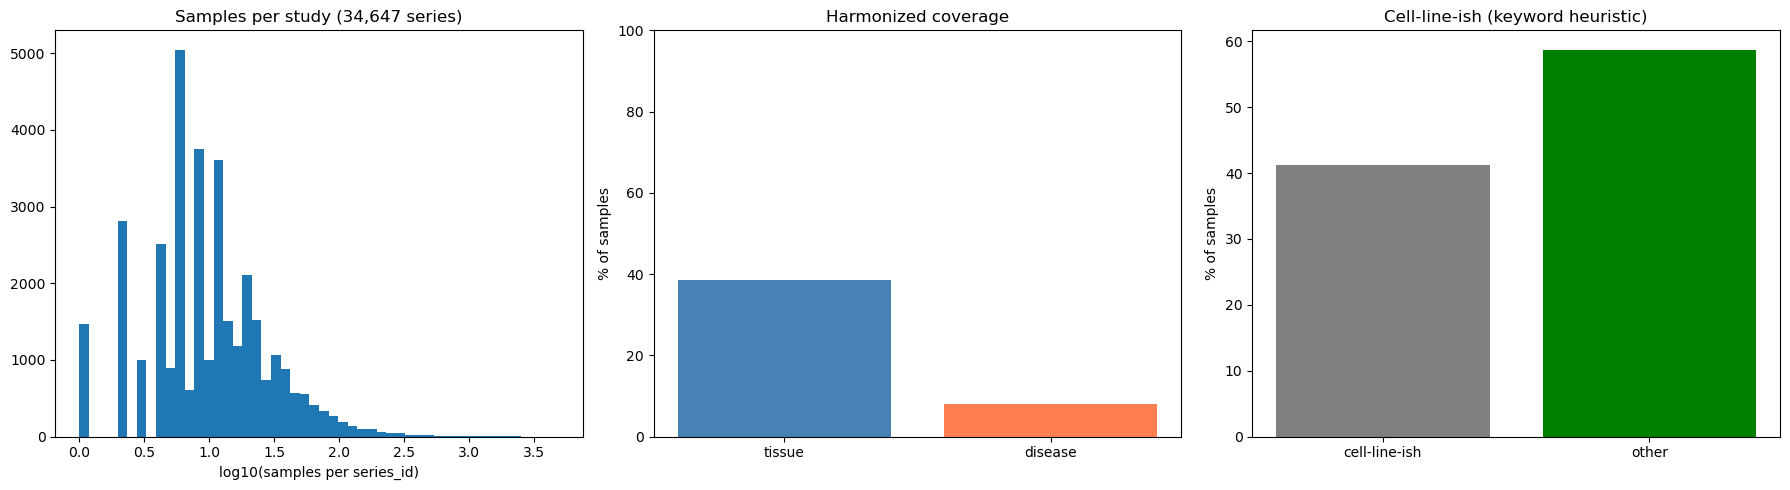

~41.3% of samples look cell-line-derived (keyword heuristic) -> motivates a Cellosaurus is_cell_line flag


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ser = meta["series_id"].value_counts()
axes[0].hist(np.log10(ser.values), bins=50)
axes[0].set_title(f"Samples per study ({meta['series_id'].nunique():,} series)")
axes[0].set_xlabel("log10(samples per series_id)")

cov = pd.Series({"tissue": (meta["tissue_harmonized"].astype(str).str.len() > 0).mean(),
                 "disease": (meta["disease_harmonized"].astype(str).str.len() > 0).mean()})
axes[1].bar(cov.index, cov.values * 100, color=["steelblue", "coral"])
axes[1].set_title("Harmonized coverage"); axes[1].set_ylabel("% of samples"); axes[1].set_ylim(0, 100)

# crude cell-line composition flag (keyword heuristic on the raw free text)
src = meta["source_name_ch1"].astype(str) + " " + meta["characteristics_ch1"].astype(str)
cl = src.str.contains(r"cell line|MCF7|HEK293|HeLa|K562|A549|HCT116|U2OS|A375|HUVEC|Jurkat",
                      case=False, regex=True)
axes[2].bar(["cell-line-ish", "other"], [cl.mean()*100, (1-cl.mean())*100], color=["gray", "green"])
axes[2].set_title("Cell-line-ish (keyword heuristic)"); axes[2].set_ylabel("% of samples")
plt.tight_layout(); plt.show()
print(f"~{cl.mean()*100:.1f}% of samples look cell-line-derived (keyword heuristic) "
      f"-> motivates a Cellosaurus is_cell_line flag")

## Dimensionality reduction (log-normalized sample)

working set for DR: 8,000 samples


C:\Users\sander\miniconda3\envs\prot_gpt\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


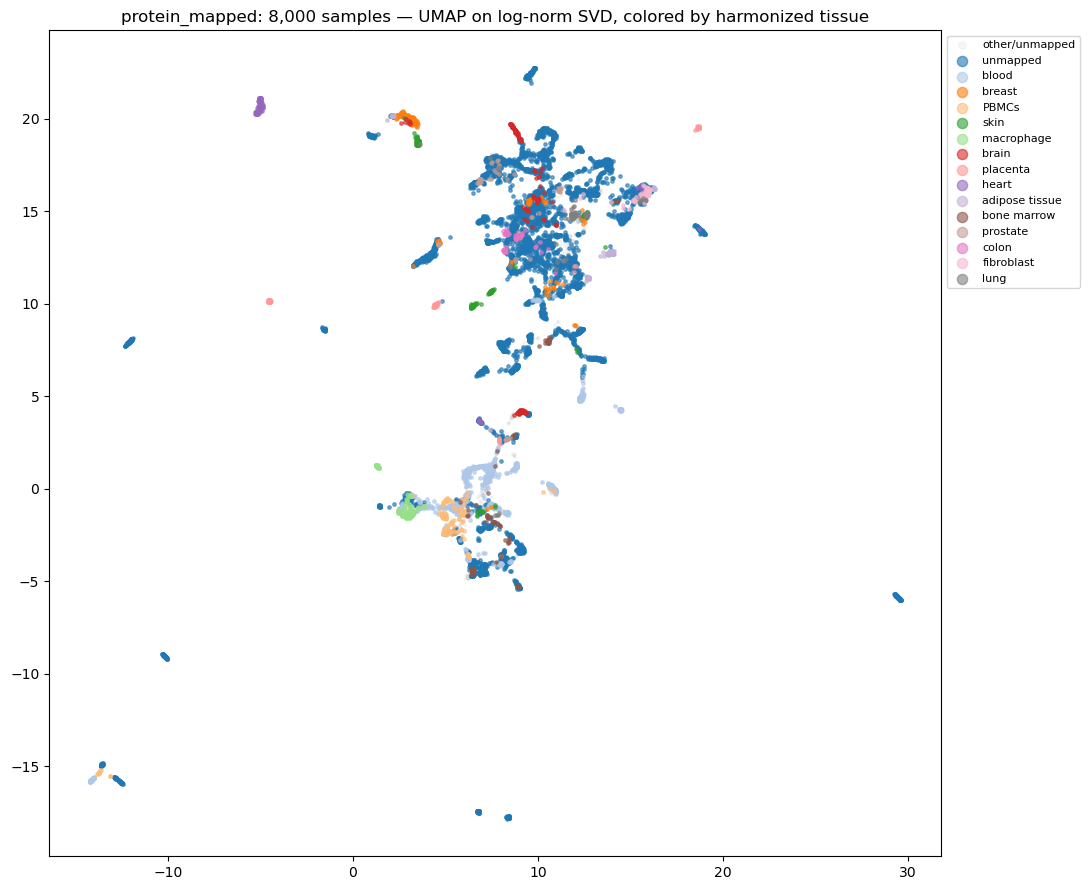

In [11]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
try:
    from umap import UMAP
    have_umap = True
except Exception:
    have_umap = False

n_dr = min(8000, Xs.shape[0])
sel = np.random.default_rng(0).choice(Xs.shape[0], n_dr, replace=False)
# library-size normalize + log1p (CPM-ish) so depth doesn't dominate the embedding
Xln = Xs[sel].astype(np.float32)
Xln = np.log1p(Xln / (Xln.sum(1, keepdims=True) + 1e-6) * 1e4)
Z = TruncatedSVD(n_components=50, random_state=0).fit_transform(Xln)
print(f"working set for DR: {n_dr:,} samples")

emb = (UMAP(n_neighbors=30, min_dist=0.3, random_state=0).fit_transform(Z) if have_umap
       else TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(Z))

md_ = meta_s.iloc[sel].reset_index(drop=True)
tis = md_["tissue_harmonized"].astype(str).replace("", "unmapped")
top = tis.value_counts().head(15).index
cols = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors)

fig, ax = plt.subplots(figsize=(11, 9))
other = ~tis.isin(top)
ax.scatter(emb[other.values, 0], emb[other.values, 1], s=3, alpha=.2, c="lightgray", label="other/unmapped")
for i, t in enumerate(top):
    m = (tis == t).values
    ax.scatter(emb[m, 0], emb[m, 1], s=6, alpha=.6, c=[cols[i % len(cols)]], label=t)
ax.legend(markerscale=3, fontsize=8, bbox_to_anchor=(1.0, 1.0), loc="upper left")
ax.set_title(f"{DATASET}: {n_dr:,} samples — {'UMAP' if have_umap else 't-SNE'} on log-norm SVD, colored by harmonized tissue")
plt.tight_layout(); plt.show()